# Pelatihan Model Analisis Sentimen untuk Review Aplikasi Paxel

# Install & Import Library

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
from collections import Counter

# Untuk deep learning dan preprocessing teks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Untuk Word2Vec
!pip install gensim
from gensim.models import Word2Vec

# Untuk Sastrawi (stopwords dan stemming Bahasa Indonesia)
!pip install Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi stopword dan stemmer Bahasa Indonesia
stop_factory = StopWordRemoverFactory()
stopwords_id = set(stop_factory.get_stop_words())
stemmer_id = StemmerFactory().create_stemmer()

In [3]:
# ambil data
df = pd.read_csv("paxel_reviews.csv")

print(df.head())

                               reviewId         userName  \
0  33abac57-e9a4-4a8a-8441-861d9c7158b8  Pengguna Google   
1  2b8d5590-4e94-47b9-ab2c-5f2075a2ca41  Pengguna Google   
2  cec769f1-b6ac-423d-9b02-387209cbfd2b  Pengguna Google   
3  7f21ec94-6198-462b-bf3c-6188cda269d8  Pengguna Google   
4  e029a810-0925-455a-9238-cf542a399a09  Pengguna Google   

                                           userImage  \
0  https://play-lh.googleusercontent.com/EGemoI2N...   
1  https://play-lh.googleusercontent.com/EGemoI2N...   
2  https://play-lh.googleusercontent.com/EGemoI2N...   
3  https://play-lh.googleusercontent.com/EGemoI2N...   
4  https://play-lh.googleusercontent.com/EGemoI2N...   

                                             content  score  thumbsUpCount  \
0   saya coba dulu ya bagus apa tidak jasa kurir nya      3              0   
1  baru coba layanan paxel hari ini semoga besok ...      5              0   
2  sy msh ada kesulitan ketik nama di kolom pneri...      4         

# Preprocessing Teks Data

In [4]:
def normalisasi_teks(text):
    # Basic cleaning
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # Hapus URL
    text = re.sub(r'\d+', '', text)  # Hapus angka
    text = re.sub(r'[^a-z\s]', '', text)  # Hapus karakter non-alphabet
    text = re.sub(r'\s+', ' ', text).strip()  # Hapus spasi berlebih

    # Normalisasi kata tidak baku (contoh: "laamaaa" -> "lama")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)  # Kurangi huruf berulang >2x

    return text

def preprocessing_indonesia(text):
    # 1. Normalisasi
    cleaned = normalisasi_teks(text)
    # 2. Tokenisasi
    tokens = cleaned.split()
    # 3. Stopword removal
    tokens = [word for word in tokens if word not in stopwords_id]
    # 4. Stemming
    tokens = [stemmer_id.stem(word) for word in tokens]
    return tokens

# Terapkan ke DataFrame
df['tokens'] = df['content'].apply(preprocessing_indonesia)

# Contoh hasil
print("\nContoh Labelisasi:")
print(df[['content', 'tokens']].head(3))


Contoh Labelisasi:
                                             content  \
0   saya coba dulu ya bagus apa tidak jasa kurir nya   
1  baru coba layanan paxel hari ini semoga besok ...   
2  sy msh ada kesulitan ketik nama di kolom pneri...   

                                              tokens  
0         [coba, dulu, bagus, apa, jasa, kurir, nya]  
1  [baru, coba, layan, paxel, hari, moga, besok, ...  
2  [sy, msh, sulit, ketik, nama, kolom, pnerima, ...  


# Labeling

In [5]:
# Labeling berdasarkan score (Score ≤ 2: negatif, Score = 3: netral, Score ≥ 4: positif)
def label_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

df['label'] = df['score'].apply(label_sentiment)
print("Contoh data setelah preprocessing dan labeling:")
print(df[['content', 'tokens', 'score', 'label']].head(5))

Contoh data setelah preprocessing dan labeling:
                                             content  \
0   saya coba dulu ya bagus apa tidak jasa kurir nya   
1  baru coba layanan paxel hari ini semoga besok ...   
2  sy msh ada kesulitan ketik nama di kolom pneri...   
3                           kurirnya lamaaa bangettt   
4                                  paxel tepat waktu   

                                              tokens  score    label  
0         [coba, dulu, bagus, apa, jasa, kurir, nya]      3   netral  
1  [baru, coba, layan, paxel, hari, moga, besok, ...      5  positif  
2  [sy, msh, sulit, ketik, nama, kolom, pnerima, ...      4  positif  
3                            [kurir, lamaa, bangett]      2  negatif  
4                              [paxel, tepat, waktu]      5  positif  


In [6]:
# Pemetaan label ke angka, kemudian one-hot encoding
label_mapping = {'negatif': 0, 'netral': 1, 'positif': 2}
df['label_num'] = df['label'].map(label_mapping)
y_all = to_categorical(df['label_num'].values, num_classes=3)

# Uji Model

## 1. TF-IDF + MLP (80/20 Split)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Gabungkan token menjadi teks untuk TF-IDF
df['preprocessed_text'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

# Ekstraksi fitur dengan TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df['preprocessed_text']).toarray()
print("Bentuk matriks TF-IDF:", X_tfidf.shape)

# Bagi data (80% train, 20% test)
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y_all, test_size=0.2, random_state=42)

# Model MLP untuk TF-IDF
model_tfidf = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])
model_tfidf.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_tfidf.summary()

history_tfidf = model_tfidf.fit(X_train_tfidf, y_train_tfidf,
                                validation_data=(X_test_tfidf, y_test_tfidf),
                                epochs=10, batch_size=64)

Bentuk matriks TF-IDF: (10000, 5000)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,579 (2.47 MB)

 Trainable params: 648,579 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7357 - loss: 0.8013 - val_accuracy: 0.8565 - val_loss: 0.4228
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8849 - loss: 0.3503 - val_accuracy: 0.8725 - val_loss: 0.3609
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9104 - loss: 0.2774 - val_accuracy: 0.8745 - val_loss: 0.3642
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9228 - loss: 0.2346 - val_accuracy: 0.8735 - val_loss: 0.3742
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9323 - loss: 0.1970 - val_accuracy: 0.8625 - val_loss: 0.4141
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9402 - loss: 0.1731 - val_accuracy: 0.8595 - val_loss: 0.4364
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9553 - loss: 0.1477 - val_accuracy: 0.8590 - val_loss: 0.4673
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9688 - loss: 0.1264 - val_accu

## 2. Word2Vec Average + MLP (80/20 Split)

In [8]:
# Latih model Word2Vec pada seluruh token
sentences = df['tokens'].tolist()
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)
vector_size = word2vec_model.vector_size

def get_average_vector(tokens, model, vector_size):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

df['w2v_features'] = df['tokens'].apply(lambda tokens: get_average_vector(tokens, word2vec_model, vector_size))
X_w2v = np.vstack(df['w2v_features'].values)
print("Bentuk matriks Word2Vec (average):", X_w2v.shape)

# Bagi data (80/20 split)
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y_all, test_size=0.2, random_state=42)

# Model MLP untuk fitur Word2Vec (average)
model_w2v_mlp = Sequential([
    Dense(128, activation='relu', input_shape=(vector_size,)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])
model_w2v_mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_w2v_mlp.summary()

history_w2v_mlp = model_w2v_mlp.fit(X_train_w2v, y_train_w2v,
                                    validation_data=(X_test_w2v, y_test_w2v),
                                    epochs=10, batch_size=64)

Bentuk matriks Word2Vec (average): (10000, 100)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6877 - loss: 0.7962 - val_accuracy: 0.7690 - val_loss: 0.5229
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7939 - loss: 0.5261 - val_accuracy: 0.7885 - val_loss: 0.5140
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8041 - loss: 0.5018 - val_accuracy: 0.8145 - val_loss: 0.5007
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8126 - loss: 0.4938 - val_accuracy: 0.8070 - val_loss: 0.4979
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8081 - loss: 0.4975 - val_accuracy: 0.8085 - val_loss: 0.4944
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8132 - loss: 0.4892 - val_accuracy: 0.8170 - val_loss: 0.4900
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8120 - loss: 0.4974 - val_accuracy: 0.8125 - val_loss: 0.4939
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8271 - loss: 0.4651 - val_accuracy: 0.

## 3. Word2Vec-Initiated Embedding + LSTM (70/30 Split)

In [9]:
tokenizer_seq = Tokenizer(num_words=10000)
tokenizer_seq.fit_on_texts(df['preprocessed_text'])
sequences = tokenizer_seq.texts_to_sequences(df['preprocessed_text'])
max_seq_len = 100
X_seq = pad_sequences(sequences, maxlen=max_seq_len)
print("Bentuk sequence:", X_seq.shape)

# Buat embedding matrix dari Word2Vec
word_index = tokenizer_seq.word_index
embedding_dim = vector_size  # gunakan vektor Word2Vec (100)
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))

# Bagi data dengan rasio 70/30
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_all, test_size=0.3, random_state=42)

# Model LSTM dengan Embedding yang diinisialisasi dari Word2Vec
model_lstm = Sequential([
    Embedding(input_dim=len(word_index) + 1,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=max_seq_len,
              trainable=True),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(3, activation='softmax')
])
model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

history_lstm = model_lstm.fit(X_train_seq, y_train_seq,
                              validation_data=(X_test_seq, y_test_seq),
                              epochs=10, batch_size=64)

Bentuk sequence: (10000, 100)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       873,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 873,000 (3.33 MB)

 Trainable params: 873,000 (3.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 32s 259ms/step - accuracy: 0.7946 - loss: 0.6014 - val_accuracy: 0.8343 - val_loss: 0.4450
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 39s 248ms/step - accuracy: 0.8590 - loss: 0.3975 - val_accuracy: 0.8670 - val_loss: 0.3771
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 41s 245ms/step - accuracy: 0.8928 - loss: 0.3180 - val_accuracy: 0.8790 - val_loss: 0.3525
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 41s 247ms/step - accuracy: 0.9038 - loss: 0.2810 - val_accuracy: 0.8767 - val_loss: 0.3563
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 259ms/step - accuracy: 0.9241 - loss: 0.2221 - val_accuracy: 0.8607 - val_loss: 0.4091
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 40s 248ms/step - accuracy: 0.9390 - loss: 0.1770 - val_accuracy: 0.8557 - val_loss: 0.4378
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 249ms/step - accuracy: 0.9481 - loss: 0.1575 - val_accuracy: 0.8427 - val_loss: 0.5210
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 259ms/step - accuracy: 0.9579 - loss: 0

Akurasi TF-IDF + MLP: 85.15%
Akurasi Word2Vec Average + MLP: 81.95%
Akurasi Word2Vec Sequence + LSTM: 83.20%


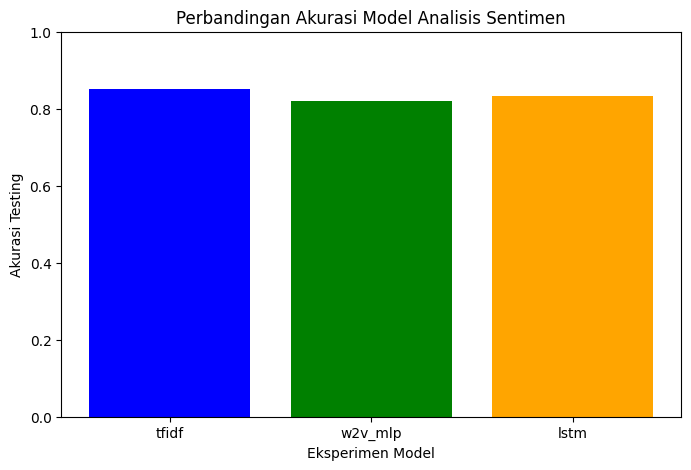

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Evaluasi ketiga model pada data testing masing-masing.
acc_tfidf = model_tfidf.evaluate(X_test_tfidf, y_test_tfidf, verbose=0)[1]
acc_w2v = model_w2v_mlp.evaluate(X_test_w2v, y_test_w2v, verbose=0)[1]
acc_lstm = model_lstm.evaluate(X_test_seq, y_test_seq, verbose=0)[1]

print("Akurasi TF-IDF + MLP: {:.2f}%".format(acc_tfidf * 100))
print("Akurasi Word2Vec Average + MLP: {:.2f}%".format(acc_w2v * 100))
print("Akurasi Word2Vec Sequence + LSTM: {:.2f}%".format(acc_lstm * 100))

# Simpan hasil akurasi dalam dictionary
model_accuracies = {
    'tfidf': acc_tfidf,
    'w2v_mlp': acc_w2v,
    'lstm': acc_lstm
}

# Tampilkan perbandingan dalam grafik batang
models = list(model_accuracies.keys())
accuracies = [model_accuracies[m] for m in models]
plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Eksperimen Model')
plt.ylabel('Akurasi Testing')
plt.ylim([0,1])
plt.title('Perbandingan Akurasi Model Analisis Sentimen')
plt.show()

**Insight:**
- model berbasis TF-IDF dengan pelatihan MLP memiliki hasil akurasi terbaik dari 3 model tersebut, maka dari itu model ini akan digunakan untuk inferensi

In [12]:
import pickle

# Simpan vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Simpan model
with open('mlp_model.pkl', 'wb') as f:
    pickle.dump(model_tfidf, f)